Data shape: (8000, 16, 2)


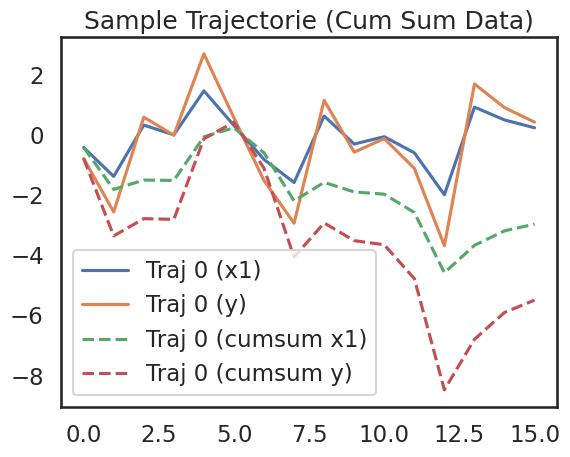

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import torch
from jax.tree_util import tree_map
from torch.utils import data
import math
from scipy.stats import wasserstein_distance
from sklearn.neighbors import NearestNeighbors
import diffrax

# --- Configuration ---
CONFIG = {
    "seed": 2026,
    "n_epochs": 2000,
    "print_every": 100,
    "num_traj": 10000,
    "batch_size": 512,
    "seq_len": 16,
    "seq_dim": 2,
    "ar_train_mode": False,
    "n_refine_steps": 10,
    "d_model": 128,
    "lr": 3e-4
}

# Set seeds
key = jax.random.PRNGKey(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])

sns.set(style="white", context="talk")

#---- Generate Cumulative Sum Data ---
def generate_cumsum_data(num_traj, seq_len, seq_dim):
    # np.random.seed(seed)

    ## For each traj, we want y_t = w x_t. First we sample x_t
    # xs = np.random.randn(num_traj, seq_len, seq_dim-1)
    xs = np.random.normal(size=(num_traj, seq_len, seq_dim-1), scale=1)
    # xs = np.random.uniform(low=-0.1, high=0.1, size=(num_traj, seq_len, seq_dim-1))

    ## Sample a linear transformation vector w
    w = np.random.randn(num_traj, seq_dim-1)
    
    ## Compute y_t = w x_t (dot product along last dim)
    ys = np.einsum('ijk,ik->ij', xs, w)
    
    ## Now we concatenate xs and ys to have shape (num_traj, seq_len, seq_dim)
    data = np.concatenate([xs, ys[..., None]], axis=-1)

    ## Save data as numpy arrays, proportion 0.8 train, 0.2 test
    split_idx = int(num_traj * 0.8)

    return data[:split_idx], data[split_idx:]

train_data, test_data = generate_cumsum_data(num_traj=CONFIG["num_traj"],
                                            seq_len=CONFIG["seq_len"], 
                                            seq_dim=CONFIG["seq_dim"])

print("Data shape:", train_data.shape)
# Plot a few trajectories
for i in range(1):
    plt.plot(train_data[i, :, 0], label=f'Traj {i} (x1)')
    plt.plot(train_data[i, :, -1], label=f'Traj {i} (y)')
    # plt.plot(data[i, :, 1], label=f'Traj {i} (x2)')

    ## DO a cumsum before plotting
    plt.plot(np.cumsum(train_data[i, :, 0]), "--", label=f'Traj {i} (cumsum x1)')
    plt.plot(np.cumsum(train_data[i, :, -1]), "--", label=f'Traj {i} (cumsum y)')

plt.legend()
plt.title("Sample Trajectorie (Cum Sum Data)")
plt.show()

In [ ]:
class RandomNormalDataset(data.Dataset):
    def __init__(self, data, cum_sum=False):
        # self.data = torch.from_numpy(data).float()
        self.data = data
        self.cum_sum = cum_sum

        ## We want to 

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        traj = self.data[idx]       ## Shape (seq_len, seq_dim)
        if self.cum_sum:
            # traj = torch.cumsum(traj, dim=0)
            traj = np.cumsum(traj, axis=0)
        
        # X is the entire traj (except last row last col, Y is the last dim)
        y = traj[:, -1:].copy()        # Last dim is target
        traj[-1, -1] = 0.0              # Zero out last point of target
        x = traj

        return x, y


# def numpy_collate(batch):
# #   return tree_map(np.asarray, data.default_collate(batch))
#   return tree_map(np.asarray, batch)

def numpy_collate(batch):
    # 'batch' is a list of tuples: [(x1, y1), (x2, y2), ..., (x25, y25)]
    
    # 1. Unzip the batch into separate lists for x and y
    # elements becomes: [(x1, x2, ...), (y1, y2, ...)]
    elements = list(zip(*batch))
    
    # 2. Stack them into single numpy arrays
    # xs becomes shape (batch_size, seq_len, seq_dim)
    # ys becomes shape (batch_size, seq_len, 1)
    xs = np.stack(elements[0])
    ys = np.stack(elements[1])
    
    return xs, ys


train_dataset = RandomNormalDataset(train_data, cum_sum=False)
train_loader = data.DataLoader(train_dataset, 
                               batch_size=CONFIG["batch_size"], 
                               shuffle=True, 
                               collate_fn=numpy_collate, 
                               num_workers=24)

In [ ]:
# --- 2. Transformer Models (Decoder-Only) ---

class PositionalEncoding(eqx.Module):
    embedding: jax.Array
    def __init__(self, d_model: int, max_len: int = 2000):
        pe = jnp.zeros((max_len, d_model))
        position = jnp.arange(0, max_len, dtype=jnp.float32)[:, jnp.newaxis]
        div_term = jnp.exp(jnp.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = pe.at[:, 0::2].set(jnp.sin(position * div_term))
        pe = pe.at[:, 1::2].set(jnp.cos(position * div_term))
        self.embedding = pe
    def __call__(self, x, start_idx=0):
        return x + self.embedding[start_idx : start_idx + x.shape[0], :]

class TransformerBlock(eqx.Module):
    attention: eqx.nn.MultiheadAttention
    norm1: eqx.nn.LayerNorm
    mlp: eqx.nn.MLP
    norm2: eqx.nn.LayerNorm
    
    def __init__(self, d_model, n_heads, d_ff, dropout, key):
        k1, k2 = jax.random.split(key)
        self.attention = eqx.nn.MultiheadAttention(
            num_heads=n_heads, query_size=d_model, dropout_p=dropout, key=k1
        )
        self.norm1 = eqx.nn.LayerNorm(d_model)
        self.mlp = eqx.nn.MLP(
            in_size=d_model, out_size=d_model, width_size=d_ff, depth=1, activation=jax.nn.gelu, key=k2
        )
        self.norm2 = eqx.nn.LayerNorm(d_model)

    def __call__(self, x, mask=None, key=None):
        attn_out = self.attention(x, x, x, mask=mask, key=key)
        x = jax.vmap(self.norm1)(x + attn_out)
        mlp_out = jax.vmap(self.mlp)(x)
        x = jax.vmap(self.norm2)(x + mlp_out)
        return x

class DecoderOnlyTransformer(eqx.Module):
    embedding: eqx.nn.Linear
    pos_encoder: PositionalEncoding
    blocks: list
    output_projection: eqx.nn.Linear
    refinement_mlp: eqx.nn.MLP

    d_model: int = eqx.field(static=True)
    n_substeps: int = eqx.field(static=True)
    use_refinement: bool = eqx.field(static=True)

    def __init__(self, input_dim, d_model, n_heads, n_layers, d_ff, n_substeps, max_len, use_refinement, key):
        self.d_model = d_model
        self.n_substeps = n_substeps
        self.use_refinement = use_refinement
        
        keys = jax.random.split(key, 5)
        self.embedding = eqx.nn.Linear(input_dim, d_model, key=keys[0])
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_len)
        
        self.blocks = [
            TransformerBlock(d_model, n_heads, d_ff, dropout=0.0, key=k)
            for k in jax.random.split(keys[1], n_layers)
        ]
        
        self.output_projection = eqx.nn.Linear(d_model, 1, key=keys[2])
        # Zero Init Output
        self.output_projection = eqx.tree_at(
            lambda l: (l.weight, l.bias), 
            self.output_projection, 
            (jnp.zeros_like(self.output_projection.weight), jnp.zeros_like(self.output_projection.bias))
        )

        self.refinement_mlp = eqx.nn.MLP(
            in_size=d_model * 2, out_size=input_dim, width_size=d_ff, depth=1, activation=jax.nn.gelu, key=keys[3]
        )
        # Zero Init Refinement
        self.refinement_mlp = eqx.tree_at(
            lambda m: (m.layers[-1].weight, m.layers[-1].bias),
            self.refinement_mlp,
            (jnp.zeros_like(self.refinement_mlp.layers[-1].weight), jnp.zeros_like(self.refinement_mlp.layers[-1].bias))
        )

    def make_causal_mask(self, seq_len):
        idx = jnp.arange(seq_len)
        return idx[:, None] < idx[None, :]

    def refine_step(self, start_val, context_h):
        def loop_fn(i, curr_val):
            w_emb = self.embedding(curr_val) * jnp.sqrt(self.d_model)
            combined = jnp.concatenate([w_emb, context_h])
            delta = self.refinement_mlp(combined)
            return curr_val + delta
        return jax.lax.fori_loop(0, self.n_substeps, loop_fn, start_val)

    def __call__(self, input_seqs, key=None):
        
        def single_forward(input_seq, key):
            x = jax.vmap(self.embedding)(input_seq) * jnp.sqrt(self.d_model)
            x = self.pos_encoder(x)
            mask = self.make_causal_mask(x.shape[0])
            for block in self.blocks:
                x = block(x, mask=mask, key=key)
            
            if not self.use_refinement:
                y = jax.vmap(self.output_projection)(x)
            else:
                y = jax.vmap(self.refine_step)(input_seq, x)

            return y
        
        keys = jax.random.split(key, input_seqs.shape[0])
        return jax.vmap(single_forward)(input_seqs, keys)

In [ ]:
# --- 4. Training Setup & Comparison ---

# Initialize Models
key, k1, k2, k3 = jax.random.split(key, 4)

max_seq_len = max(train_data.shape[1], test_data.shape[1])
models = {
    "Transformer": DecoderOnlyTransformer(
        input_dim=CONFIG["seq_dim"], 
        d_model=CONFIG["d_model"], 
        n_heads=1, 
        n_layers=1, 
        d_ff=128,
        n_substeps=CONFIG["n_refine_steps"], 
        max_len=CONFIG["seq_len"], 
        use_refinement=False, 
        key=k1
    )
}

# Optimizers (One per model)
optimizers = {name: optax.adamw(CONFIG["lr"]) for name in models}
opt_states = {name: opt.init(eqx.filter(model, eqx.is_inexact_array)) 
              for name, (model, opt) in zip(models.keys(), zip(models.values(), optimizers.values()))}

# Train Step
@eqx.filter_jit
def train_step(model, optimizer, opt_state, batch, key):
    Xs, Ys = batch
    
    def loss_fn(m, x, y, k):
        # Transformer
        y_hat = m(x, key=k)

        indices = jnp.arange(x.shape[1])
        # indices = jnp.array([-1])

        return jnp.mean((y_hat[:, indices] - y[:, indices]) ** 2)

    loss_val, grads = eqx.filter_value_and_grad(loss_fn)(model, Xs, Ys, key)

    updates, opt_state = optimizer.update(grads, opt_state, eqx.filter(model, eqx.is_inexact_array))
    model = eqx.apply_updates(model, updates)

    return model, opt_state, loss_val

# Training Loop
loss_history = {name: [] for name in models}

print(f"Training 1 models: {list(models.keys())}")

for epoch in range(CONFIG["n_epochs"]):
    batch_losses = {name: [] for name in models}
    
    for batch in train_loader:
        # batch = jnp.array(batch)
        key, subkey = jax.random.split(key)
        
        for name in models:
            models[name], opt_states[name], loss = train_step(
                models[name], optimizers[name], opt_states[name], batch, subkey
            )
            batch_losses[name].append(loss)

    for name in models:
        avg = np.mean(batch_losses[name])
        loss_history[name].append(avg)
        
    if (epoch+1) % CONFIG["print_every"] == 0:
        print(f"Epoch {epoch+1}: " + ", ".join([f"{n}: {l:.5f}" for n, l in zip(loss_history.keys(), [h[-1] for h in loss_history.values()])]))

Training 1 models: ['Transformer']


/home/gb21553/miniconda3/envs/jax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/home/gb21553/miniconda3/envs/jax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/home/gb21553/miniconda3/envs/jax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/home/gb21553/miniconda3/envs/jax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely

Epoch 100: Transformer: 0.06058
Epoch 200: Transformer: 0.04162
Epoch 300: Transformer: 0.01735
Epoch 400: Transformer: 0.01155
Epoch 500: Transformer: 0.00911
Epoch 600: Transformer: 0.00870
Epoch 700: Transformer: 0.00791
Epoch 800: Transformer: 0.00661
Epoch 900: Transformer: 0.00572
Epoch 1000: Transformer: 0.00572
Epoch 1100: Transformer: 0.00410
Epoch 1200: Transformer: 0.00471
Epoch 1300: Transformer: 0.00381
Epoch 1400: Transformer: 0.00376
Epoch 1500: Transformer: 0.00328
Epoch 1600: Transformer: 0.00302
Epoch 1700: Transformer: 0.00298
Epoch 1800: Transformer: 0.00265
Epoch 1900: Transformer: 0.00294
Epoch 2000: Transformer: 0.00350


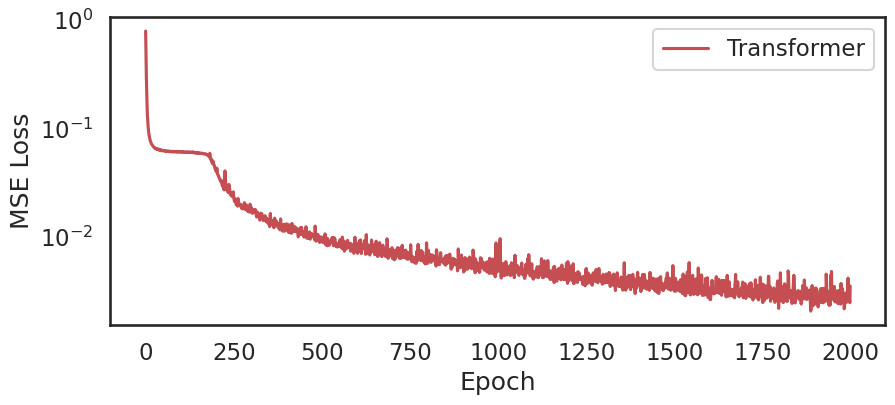

In [ ]:
# Plot Training Curves
colors = ['r', 'b', 'g']
plt.figure(figsize=(10, 4))
for name, losses in loss_history.items():
    plt.plot(losses, label=name, color=colors.pop(0))
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.yscale('log')
# plt.title("Training Loss Comparison")
plt.legend()
plt.show()

In [ ]:
# --- 5. Metrics & Comparison ---

test_dataset = RandomNormalDataset(test_data, cum_sum=False)
test_loader = data.DataLoader(test_dataset, batch_size=test_data.shape[0], shuffle=False, collate_fn=numpy_collate, num_workers=24)

def compute_metrics(model, test_loader, key):
    # Standard evaluation params
    # test_data of shape (num_traj, seq_len, seq_dim)
    # test_data = jnp.asarray(test_data)
    batch = next(iter(test_loader))

    Xs, Ys = batch
    Ys_hat = model(Xs, key=key)

    last_Y = Ys[:, -1, :]  # Shape (batch_size, 1)
    last_Y_hat = Ys_hat[:, -1, :]  # Shape (batch_size, 1)

    # JAX Metrics
    mse = jnp.mean((last_Y_hat - last_Y) ** 2)
    mae = jnp.mean(jnp.abs(last_Y_hat - last_Y))
    
    return mse, mae

print(f"{'Model':<25} | {'MSE':<10} | {'MAE':<10} | {'Wass.':<10} | {'FD':<10}")
print("-" * 75)

metrics_results = {}
for name, model in models.items():
    mse, mae = compute_metrics(model = model, test_loader=test_loader, key=key)
    metrics_results[name] = (mse, mae)
    print(f"{name:<25} | {mse:.5f}    | {mae:.5f}     ")

Model                     | MSE        | MAE        | Wass.      | FD        
---------------------------------------------------------------------------
Transformer               | 0.11240    | 0.08832     


/home/gb21553/miniconda3/envs/jax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/home/gb21553/miniconda3/envs/jax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


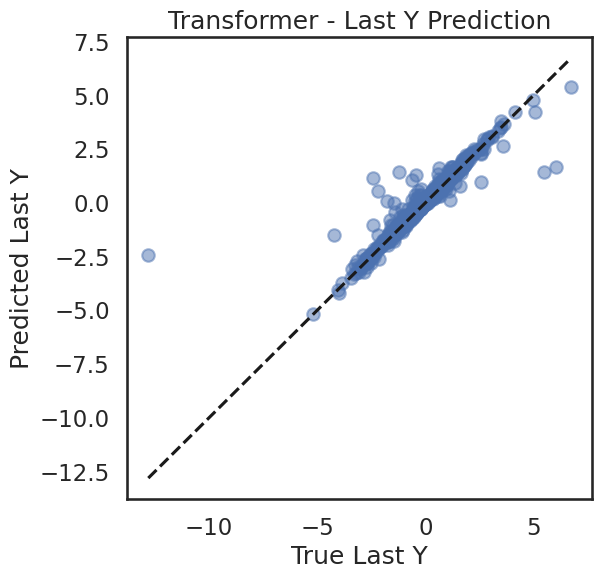

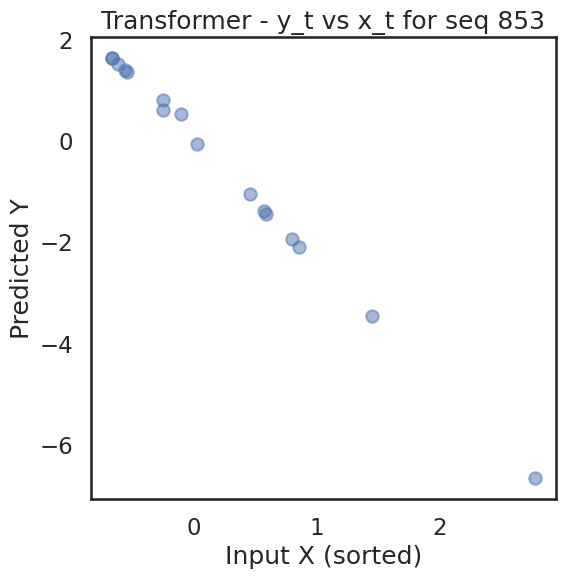

In [ ]:
## We want to plot the last y hat against the true last y for the test set
batch = next(iter(test_loader))
Xs, Ys = batch

for name, model in models.items():
    Ys_hat = model(Xs, key=key)
    last_Y = Ys[:, -1, :]  # Shape (batch_size, 1)
    last_Y_hat = Ys_hat[:, -1, :]
    plt.figure(figsize=(6, 6))
    plt.scatter(last_Y, last_Y_hat, alpha=0.5)
    plt.xlabel("True Last Y")
    plt.ylabel("Predicted Last Y")
    plt.title(f"{name} - Last Y Prediction")
    plt.plot([last_Y.min(), last_Y.max()], [last_Y.min(), last_Y.max()], 'k--')  # Diagonal line
    plt.show()


    ## PLot x (1D) agianst pred y (1D) for all steps in a random sequence
    seq_idx = np.random.randint(0, Xs.shape[0])
    x = Xs[seq_idx, :, 0]  # Shape (seq_len,)
    ## reorder x
    x_ids = np.argsort(x)
    x_sorted = x[x_ids]
    y_sorted = Ys_hat[seq_idx, :, 0][x_ids]
    plt.figure(figsize=(6, 6))
    plt.scatter(x_sorted, y_sorted, alpha=0.5)
    plt.xlabel("Input X (sorted)")
    plt.ylabel("Predicted Y")
    plt.title(f"{name} - y_t vs x_t for seq {seq_idx}")
    plt.show()

jax:    0.4.35
jaxlib: 0.4.34
numpy:  1.26.3
python: 3.12.0 | packaged by Anaconda, Inc. | (main, Oct  2 2023, 17:29:18) [GCC 11.2.0]
device info: NVIDIA GeForce RTX 4080-1, 1 local devices"
process_count: 1
platform: uname_result(system='Linux', node='it101714', release='5.15.0-161-generic', version='#171-Ubuntu SMP Sat Oct 11 08:17:01 UTC 2025', machine='x86_64')


$ nvidia-smi
Fri Feb 13 12:26:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|================================

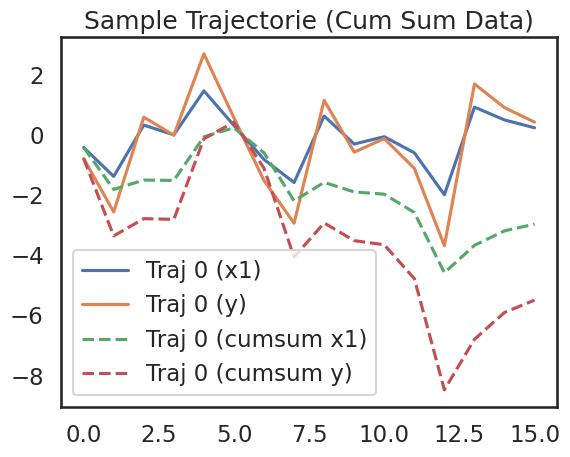

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import torch
from jax.tree_util import tree_map
from torch.utils import data
import math

## Print JAX info
jax.print_environment_info()


# --- Configuration ---
CONFIG = {
    "seed": 2026,
    "n_epochs": 2000,
    "print_every": 100,
    "num_traj": 10000,
    "batch_size": 512,
    "seq_len": 16,
    "seq_dim": 2,
    "cum_sum": True,
    "ar_train_mode": False,
    "n_refine_steps": 10,
    "d_model": 128,
    "lr": 3e-4
}

# Set seeds
key = jax.random.PRNGKey(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])

sns.set(style="white", context="talk")

#---- Generate Cumulative Sum Data ---
def generate_cumsum_data(num_traj, seq_len, seq_dim):
    # np.random.seed(seed)

    ## For each traj, we want y_t = w x_t. First we sample x_t
    # xs = np.random.randn(num_traj, seq_len, seq_dim-1)
    xs = np.random.normal(size=(num_traj, seq_len, seq_dim-1), scale=1)
    # xs = np.random.uniform(low=-0.1, high=0.1, size=(num_traj, seq_len, seq_dim-1))

    ## Sample a linear transformation vector w
    w = np.random.randn(num_traj, seq_dim-1)
    
    ## Compute y_t = w x_t (dot product along last dim)
    ys = np.einsum('ijk,ik->ij', xs, w)
    
    ## Now we concatenate xs and ys to have shape (num_traj, seq_len, seq_dim)
    data = np.concatenate([xs, ys[..., None]], axis=-1)

    ## Save data as numpy arrays, proportion 0.8 train, 0.2 test
    split_idx = int(num_traj * 0.8)

    return data[:split_idx], data[split_idx:]

train_data, test_data = generate_cumsum_data(num_traj=CONFIG["num_traj"],
                                            seq_len=CONFIG["seq_len"], 
                                            seq_dim=CONFIG["seq_dim"])

print("Data shape:", train_data.shape)
# Plot a few trajectories
for i in range(1):
    plt.plot(train_data[i, :, 0], label=f'Traj {i} (x1)')
    plt.plot(train_data[i, :, -1], label=f'Traj {i} (y)')
    # plt.plot(data[i, :, 1], label=f'Traj {i} (x2)')

    ## DO a cumsum before plotting
    plt.plot(np.cumsum(train_data[i, :, 0]), "--", label=f'Traj {i} (cumsum x1)')
    plt.plot(np.cumsum(train_data[i, :, -1]), "--", label=f'Traj {i} (cumsum y)')

plt.legend()
plt.title("Sample Trajectorie (Cum Sum Data)")
plt.show()

In [ ]:
class RandomNormalDataset(data.Dataset):
    def __init__(self, data, cum_sum=False):
        # self.data = torch.from_numpy(data).float()
        self.data = data
        self.cum_sum = cum_sum

        ## We want to 

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        traj = self.data[idx]       ## Shape (seq_len, seq_dim)
        if self.cum_sum:
            # traj = torch.cumsum(traj, dim=0)
            traj = np.cumsum(traj, axis=0)
        
        # X is the entire traj (except last row last col, Y is the last dim)
        y = traj[:, -1:].copy()        # Last dim is target
        traj[-1, -1] = 0.0              # Zero out last point of target
        x = traj

        return x, y


# def numpy_collate(batch):
# #   return tree_map(np.asarray, data.default_collate(batch))
#   return tree_map(np.asarray, batch)

def numpy_collate(batch):
    # 'batch' is a list of tuples: [(x1, y1), (x2, y2), ..., (x25, y25)]
    
    # 1. Unzip the batch into separate lists for x and y
    # elements becomes: [(x1, x2, ...), (y1, y2, ...)]
    elements = list(zip(*batch))
    
    # 2. Stack them into single numpy arrays
    # xs becomes shape (batch_size, seq_len, seq_dim)
    # ys becomes shape (batch_size, seq_len, 1)
    xs = np.stack(elements[0])
    ys = np.stack(elements[1])
    
    return xs, ys


train_dataset = RandomNormalDataset(train_data, cum_sum=CONFIG["cum_sum"])
train_loader = data.DataLoader(train_dataset, 
                               batch_size=CONFIG["batch_size"], 
                               shuffle=True, 
                               collate_fn=numpy_collate, 
                               num_workers=24)

In [ ]:
# --- 2. Transformer Models (Decoder-Only) ---

class PositionalEncoding(eqx.Module):
    embedding: jax.Array
    def __init__(self, d_model: int, max_len: int = 2000):
        pe = jnp.zeros((max_len, d_model))
        position = jnp.arange(0, max_len, dtype=jnp.float32)[:, jnp.newaxis]
        div_term = jnp.exp(jnp.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = pe.at[:, 0::2].set(jnp.sin(position * div_term))
        pe = pe.at[:, 1::2].set(jnp.cos(position * div_term))
        self.embedding = pe
    def __call__(self, x, start_idx=0):
        return x + self.embedding[start_idx : start_idx + x.shape[0], :]

class TransformerBlock(eqx.Module):
    attention: eqx.nn.MultiheadAttention
    norm1: eqx.nn.LayerNorm
    mlp: eqx.nn.MLP
    norm2: eqx.nn.LayerNorm
    
    def __init__(self, d_model, n_heads, d_ff, dropout, key):
        k1, k2 = jax.random.split(key)
        self.attention = eqx.nn.MultiheadAttention(
            num_heads=n_heads, query_size=d_model, dropout_p=dropout, key=k1
        )
        self.norm1 = eqx.nn.LayerNorm(d_model)
        self.mlp = eqx.nn.MLP(
            in_size=d_model, out_size=d_model, width_size=d_ff, depth=1, activation=jax.nn.gelu, key=k2
        )
        self.norm2 = eqx.nn.LayerNorm(d_model)

    def __call__(self, x, mask=None, key=None):
        attn_out = self.attention(x, x, x, mask=mask, key=key)
        x = jax.vmap(self.norm1)(x + attn_out)
        mlp_out = jax.vmap(self.mlp)(x)
        x = jax.vmap(self.norm2)(x + mlp_out)
        return x

class DecoderOnlyTransformer(eqx.Module):
    embedding: eqx.nn.Linear
    pos_encoder: PositionalEncoding
    blocks: list
    output_projection: eqx.nn.Linear
    refinement_mlp: eqx.nn.MLP

    d_model: int = eqx.field(static=True)
    n_substeps: int = eqx.field(static=True)
    use_refinement: bool = eqx.field(static=True)

    def __init__(self, input_dim, d_model, n_heads, n_layers, d_ff, n_substeps, max_len, use_refinement, key):
        self.d_model = d_model
        self.n_substeps = n_substeps
        self.use_refinement = use_refinement
        
        keys = jax.random.split(key, 5)
        self.embedding = eqx.nn.Linear(input_dim, d_model, key=keys[0])
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_len)
        
        self.blocks = [
            TransformerBlock(d_model, n_heads, d_ff, dropout=0.0, key=k)
            for k in jax.random.split(keys[1], n_layers)
        ]
        
        self.output_projection = eqx.nn.Linear(d_model, 1, key=keys[2])
        # Zero Init Output
        self.output_projection = eqx.tree_at(
            lambda l: (l.weight, l.bias), 
            self.output_projection, 
            (jnp.zeros_like(self.output_projection.weight), jnp.zeros_like(self.output_projection.bias))
        )

        self.refinement_mlp = eqx.nn.MLP(
            in_size=d_model * 2, out_size=input_dim, width_size=d_ff, depth=1, activation=jax.nn.gelu, key=keys[3]
        )
        # Zero Init Refinement
        self.refinement_mlp = eqx.tree_at(
            lambda m: (m.layers[-1].weight, m.layers[-1].bias),
            self.refinement_mlp,
            (jnp.zeros_like(self.refinement_mlp.layers[-1].weight), jnp.zeros_like(self.refinement_mlp.layers[-1].bias))
        )

    def make_causal_mask(self, seq_len):
        idx = jnp.arange(seq_len)
        return idx[:, None] < idx[None, :]

    def refine_step(self, start_val, context_h):
        def loop_fn(i, curr_val):
            w_emb = self.embedding(curr_val) * jnp.sqrt(self.d_model)
            combined = jnp.concatenate([w_emb, context_h])
            delta = self.refinement_mlp(combined)
            return curr_val + delta
        return jax.lax.fori_loop(0, self.n_substeps, loop_fn, start_val)

    def __call__(self, input_seqs, key=None):
        
        def single_forward(input_seq, key):
            x = jax.vmap(self.embedding)(input_seq) * jnp.sqrt(self.d_model)
            x = self.pos_encoder(x)
            mask = self.make_causal_mask(x.shape[0])
            for block in self.blocks:
                x = block(x, mask=mask, key=key)
            
            if not self.use_refinement:
                y = jax.vmap(self.output_projection)(x)
            else:
                y = jax.vmap(self.refine_step)(input_seq, x)

            return y
        
        keys = jax.random.split(key, input_seqs.shape[0])
        return jax.vmap(single_forward)(input_seqs, keys)

In [ ]:
# --- 4. Training Setup & Comparison ---

# Initialize Models
key, k1, k2, k3 = jax.random.split(key, 4)

max_seq_len = max(train_data.shape[1], test_data.shape[1])
models = {
    "Transformer": DecoderOnlyTransformer(
        input_dim=CONFIG["seq_dim"], 
        d_model=CONFIG["d_model"], 
        n_heads=1, 
        n_layers=1, 
        d_ff=128,
        n_substeps=CONFIG["n_refine_steps"], 
        max_len=CONFIG["seq_len"], 
        use_refinement=False, 
        key=k1
    )
}

# Optimizers (One per model)
optimizers = {name: optax.adamw(CONFIG["lr"]) for name in models}
opt_states = {name: opt.init(eqx.filter(model, eqx.is_inexact_array)) 
              for name, (model, opt) in zip(models.keys(), zip(models.values(), optimizers.values()))}

# Train Step
@eqx.filter_jit
def train_step(model, optimizer, opt_state, batch, key):
    Xs, Ys = batch
    
    def loss_fn(m, x, y, k):
        # Transformer
        y_hat = m(x, key=k)

        indices = jnp.arange(x.shape[1])
        # indices = jnp.array([-1])

        return jnp.mean((y_hat[:, indices] - y[:, indices]) ** 2)

    loss_val, grads = eqx.filter_value_and_grad(loss_fn)(model, Xs, Ys, key)

    updates, opt_state = optimizer.update(grads, opt_state, eqx.filter(model, eqx.is_inexact_array))
    model = eqx.apply_updates(model, updates)

    return model, opt_state, loss_val

# Training Loop
loss_history = {name: [] for name in models}

print(f"Training 1 models: {list(models.keys())}")

for epoch in range(CONFIG["n_epochs"]):
    batch_losses = {name: [] for name in models}
    
    for batch in train_loader:
        # batch = jnp.array(batch)
        key, subkey = jax.random.split(key)
        
        for name in models:
            models[name], opt_states[name], loss = train_step(
                models[name], optimizers[name], opt_states[name], batch, subkey
            )
            batch_losses[name].append(loss)

    for name in models:
        avg = np.mean(batch_losses[name])
        loss_history[name].append(avg)
        
    if (epoch+1) % CONFIG["print_every"] == 0:
        print(f"Epoch {epoch+1}: " + ", ".join([f"{n}: {l:.5f}" for n, l in zip(loss_history.keys(), [h[-1] for h in loss_history.values()])]))

Training 1 models: ['Transformer']


/home/gb21553/miniconda3/envs/jax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/home/gb21553/miniconda3/envs/jax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/home/gb21553/miniconda3/envs/jax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/home/gb21553/miniconda3/envs/jax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely

Epoch 100: Transformer: 0.11856
Epoch 200: Transformer: 0.04587
Epoch 300: Transformer: 0.03030
Epoch 400: Transformer: 0.03609
Epoch 500: Transformer: 0.02595
Epoch 600: Transformer: 0.02517
Epoch 700: Transformer: 0.02239
Epoch 800: Transformer: 0.01892
Epoch 900: Transformer: 0.01502
Epoch 1000: Transformer: 0.01293
Epoch 1100: Transformer: 0.01382
Epoch 1200: Transformer: 0.02703
Epoch 1300: Transformer: 0.01630
Epoch 1400: Transformer: 0.01136
Epoch 1500: Transformer: 0.00998
Epoch 1600: Transformer: 0.00905
Epoch 1700: Transformer: 0.00750
Epoch 1800: Transformer: 0.00908
Epoch 1900: Transformer: 0.00734
Epoch 2000: Transformer: 0.00804


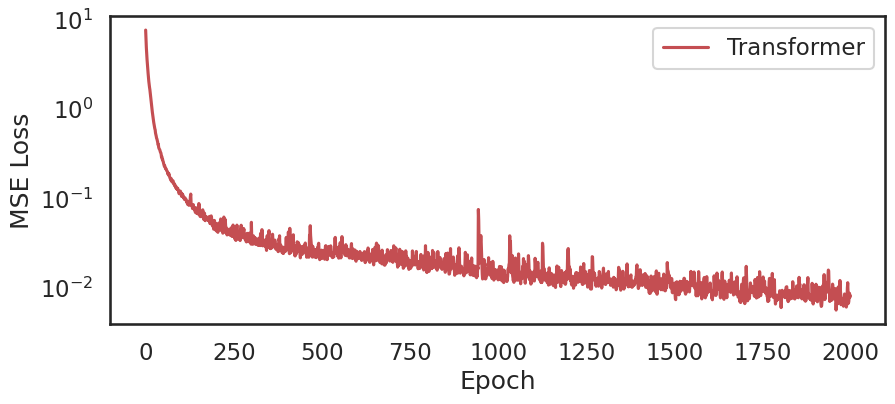

In [ ]:
# Plot Training Curves
colors = ['r', 'b', 'g']
plt.figure(figsize=(10, 4))
for name, losses in loss_history.items():
    plt.plot(losses, label=name, color=colors.pop(0))
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.yscale('log')
# plt.title("Training Loss Comparison")
plt.legend()
plt.show()

In [ ]:
# --- 5. Metrics & Comparison ---

test_dataset = RandomNormalDataset(test_data, cum_sum=CONFIG["cum_sum"])
test_loader = data.DataLoader(test_dataset, batch_size=test_data.shape[0], shuffle=False, collate_fn=numpy_collate, num_workers=24)

def compute_metrics(model, test_loader, key):
    # Standard evaluation params
    # test_data of shape (num_traj, seq_len, seq_dim)
    # test_data = jnp.asarray(test_data)
    batch = next(iter(test_loader))

    Xs, Ys = batch
    Ys_hat = model(Xs, key=key)

    last_Y = Ys[:, -1, :]  # Shape (batch_size, 1)
    last_Y_hat = Ys_hat[:, -1, :]  # Shape (batch_size, 1)

    # JAX Metrics
    mse = jnp.mean((last_Y_hat - last_Y) ** 2)
    mae = jnp.mean(jnp.abs(last_Y_hat - last_Y))
    
    return mse, mae

print(f"{'Model':<25} | {'MSE':<10} | {'MAE':<10} | {'Wass.':<10} | {'FD':<10}")
print("-" * 75)

metrics_results = {}
for name, model in models.items():
    mse, mae = compute_metrics(model = model, test_loader=test_loader, key=key)
    metrics_results[name] = (mse, mae)
    print(f"{name:<25} | {mse:.5f}    | {mae:.5f}     ")

Model                     | MSE        | MAE        | Wass.      | FD        
---------------------------------------------------------------------------
Transformer               | 0.13685    | 0.12764     


/home/gb21553/miniconda3/envs/jax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/home/gb21553/miniconda3/envs/jax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


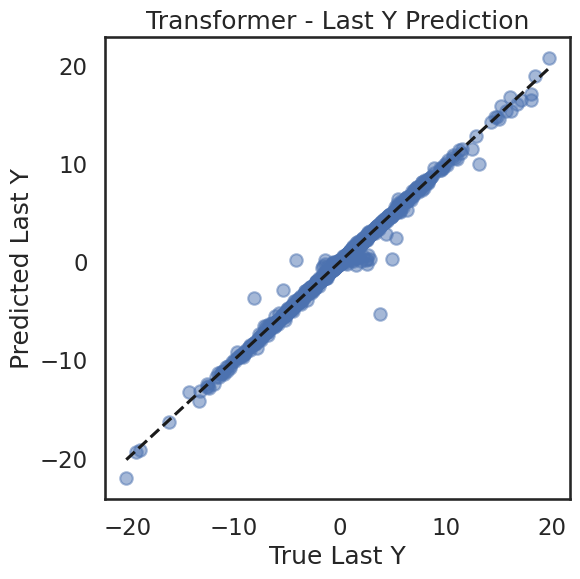

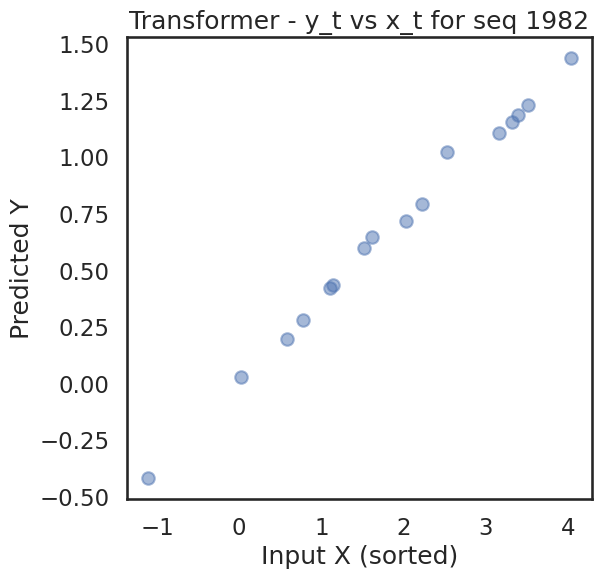

In [ ]:
## We want to plot the last y hat against the true last y for the test set
batch = next(iter(test_loader))
Xs, Ys = batch

for name, model in models.items():
    Ys_hat = model(Xs, key=key)
    last_Y = Ys[:, -1, :]  # Shape (batch_size, 1)
    last_Y_hat = Ys_hat[:, -1, :]
    plt.figure(figsize=(6, 6))
    plt.scatter(last_Y, last_Y_hat, alpha=0.5)
    plt.xlabel("True Last Y")
    plt.ylabel("Predicted Last Y")
    plt.title(f"{name} - Last Y Prediction")
    plt.plot([last_Y.min(), last_Y.max()], [last_Y.min(), last_Y.max()], 'k--')  # Diagonal line
    plt.show()

    ## PLot x (1D) agianst pred y (1D) for all steps in a random sequence
    seq_idx = np.random.randint(0, Xs.shape[0])
    x = Xs[seq_idx, :, 0]  # Shape (seq_len,)
    ## reorder x
    x_ids = np.argsort(x)
    x_sorted = x[x_ids]
    y_sorted = Ys_hat[seq_idx, :, 0][x_ids]
    plt.figure(figsize=(6, 6))
    plt.scatter(x_sorted, y_sorted, alpha=0.5)
    plt.xlabel("Input X (sorted)")
    plt.ylabel("Predicted Y")
    plt.title(f"{name} - y_t vs x_t for seq {seq_idx}")
    plt.show()